# Labs 6 - Qunatum Furier Transform

Mateusz Tabaszewski 151945

## Introduction

The Quantum Phase Estimation (QPE) algorithm is a fundamental component of many advanced quantum algorithms, serving as a critical bridge between unitary operations and the extraction of physical information. This laboratory exercise focuses on implementing the QPE algorithm using the Inverse Quantum Fourier Transform (IQFT) to estimate the phase θ associated with the eigenvalue λ of a unitary operator U. By utilizing a series of controlled-unitary gates C applied across a multi-qubit register, the algorithm encodes phase information into a quantum state that can subsequently be read out in binary notation. The primary objective is to investigate the accuracy of this estimation as a function of the number of qubits (n) used in the register, moving from a single qubit up to a 10-qubit system.

## Imports

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit_aer.primitives import Sampler
from numpy import pi
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

## Functions

In [2]:
def get_circuit(theta, num_control_qubits):
    control_register = QuantumRegister(num_control_qubits, name="Control")
    target_register = QuantumRegister(1, name="|ψ>")
    output_register = ClassicalRegister(num_control_qubits, name="Result")
    qc = QuantumCircuit(control_register, target_register, output_register)
    # Prepare the eigenvector |ψ>
    qc.x(target_register)
    qc.barrier()

    # Perform phase estimation
    for index, qubit in enumerate(control_register):
        qc.h(qubit)
        for _ in range(2**index):
            qc.cp(2 * pi * theta, qubit, target_register)
    qc.barrier()

    # Do inverse quantum Fourier transform
    qc.compose(
        QFT(num_control_qubits, inverse=True),
        inplace=True
    )

    # Measure everything
    qc.measure(range(num_control_qubits), range(num_control_qubits))
    return qc

def plot_results(qubits_list, theta_estimated_list, num_control_qubits, theta):
    relative_error_list=[]
    for i in range(len(theta_estimated_list)):
        DaneYX=((theta_estimated_list[i]-theta)/theta) *100
        relative_error_list.append(DaneYX)
    plt.title(u'Phase estimation $\\theta_e$ (where $\\theta=0.66$)')
    plt.xlabel(r' Number of qubits ')
    plt.ylabel(r'$\theta_e$')
    plt.xlim([0, num_control_qubits+0.2])
    plt.plot(qubits_list,theta_estimated_list, 'g^')
    plt.hlines(y=0.66,xmin=0.0,xmax=num_control_qubits+0.2, colors='k', linestyles='dashed')
    plt.show()
    plt.clf()


    plt.title(r'Phase estimation uncertainty $\frac{\theta_e - \theta}{\theta} \cdot 100\%$')
    plt.xlabel(r' Number of qubits ')
    plt.ylabel(r'$\frac{\theta_e - \theta}{\theta} \cdot 100\%$')
    plt.xlim([0, num_control_qubits+0.2])
    plt.plot(qubits_list,relative_error_list, 'g^')
    plt.hlines(y=0.0,xmin=0.0,xmax=num_control_qubits+0.2, colors='k', linestyles='dashed')
    plt.show()
    plt.clf()

def phase_estimation_dataframe(estimated_thetas, num_qubits, theta):
    data = {
        "n (number of qubits)": num_qubits,
        "θe (estimated phase)": estimated_thetas,
        "θ (true phase)": [theta] * len(num_qubits),
        "Relative error [%]": [
            100 * (theta_e - theta) / theta for theta_e in estimated_thetas
        ],
    }
    
    df = pd.DataFrame(data)
    return df

def plot_phase_estimation_distributions(results, num_qubits, theta):
    num_plots = len(results)
    cols = 2
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 2.5 * rows))
    axes = axes.flatten()
    
    for i, (dist, n) in enumerate(zip(results, num_qubits)):
        keys = list(dist.keys())
        values = list(dist.values())
        
        axes[i].bar(keys, values)
        axes[i].set_title(f"n = {n} qubits")
        axes[i].set_xlabel("Measured value (dh)")
        axes[i].set_ylabel("Probability")
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(
        rf"Quantum Phase Estimation Measurement Distributions ($\theta = {theta}$)",
        fontsize=14
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



def run_experiment(theta, n):
    results = []
    estimated_thetas = []
    num_qubits = []
    
    for num_control_qubits in range(1, n):
        qc = get_circuit(theta, num_control_qubits)
        result = Sampler().run(qc).result().quasi_dists[0]
        most_probable = max(result, key=result.get)
        estimated_theta = most_probable/2**num_control_qubits
        num_qubits.append(num_control_qubits)
        results.append(result)
        estimated_thetas.append(estimated_theta)
    
    return results, estimated_thetas, num_qubits

## Variables

In [3]:
num_control_qubits = 3 # For the small test below
theta_angle = 0.66
qubits_limit = 10

## Example Circuit for n = 3

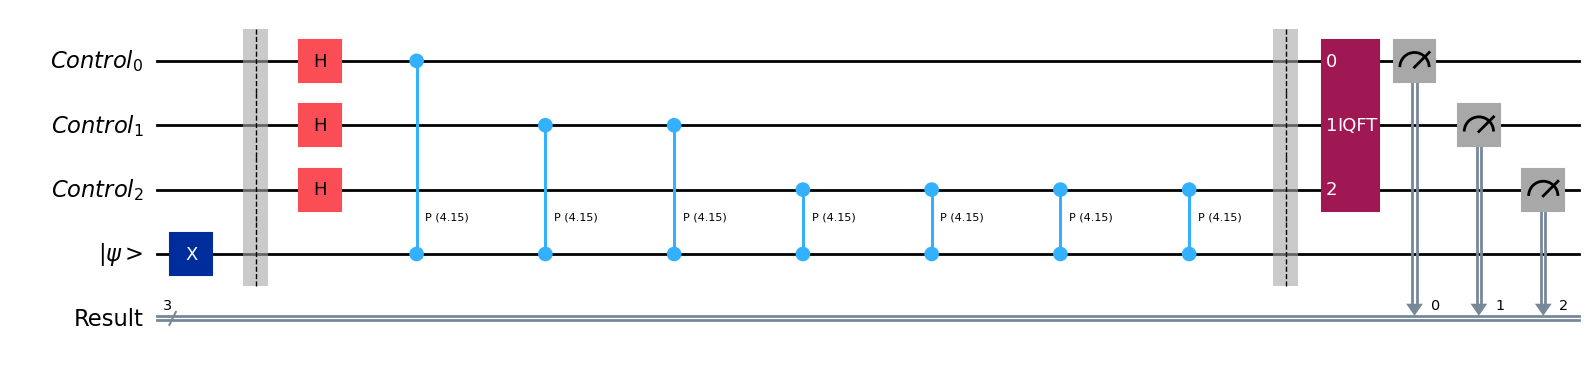

In [4]:
qc = get_circuit(theta_angle, num_control_qubits)
qc.draw('mpl')

In [5]:
display(Sampler().run(qc).result().quasi_dists[0])

{1: 0.005859375, 2: 0.0126953125, 0: 0.013671875, 3: 0.0205078125, 7: 0.0234375, 4: 0.037109375, 6: 0.1298828125, 5: 0.7568359375}

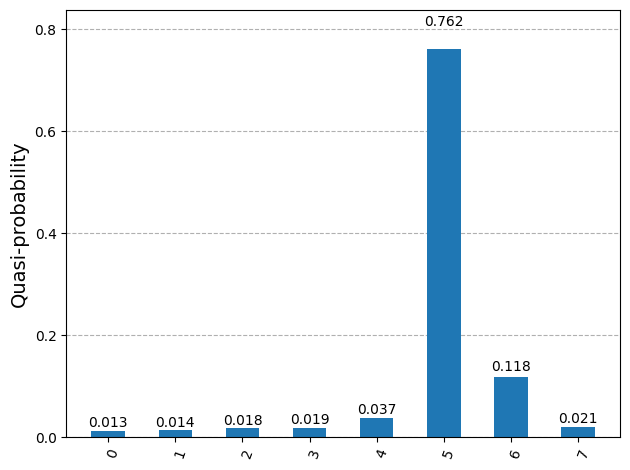

In [6]:
result = Sampler().run(qc).result()
display(plot_histogram(result.quasi_dists))

In [7]:
most_probable = max(result.quasi_dists[0], key=result.quasi_dists[0].get)

print(f"Most probable output: {most_probable}")
print(f"Estimated theta: {most_probable/2**num_control_qubits}")

Most probable output: 5
Estimated theta: 0.625


## Task 1 and 2 (Estimation for n=1...10 for Theta θ = 0.66)

In [8]:
results, estimated_thetas, num_qubits = run_experiment(theta=theta_angle, n=qubits_limit + 1)

## Task 3 - Results

### Task 3 - Table

In [9]:
results_df = phase_estimation_dataframe(
    estimated_thetas=estimated_thetas,
    num_qubits=num_qubits,
    theta=theta_angle
)

results_df

,n (number of qubits),θe (estimated phase),θ (true phase),Relative error [%]
0,1,0.500000,0.66,-24.242424
1,2,0.750000,0.66,13.636364
2,3,0.625000,0.66,-5.303030
3,4,0.687500,0.66,4.166667
4,5,0.656250,0.66,-0.568182
5,6,0.656250,0.66,-0.568182
6,7,0.656250,0.66,-0.568182
7,8,0.660156,0.66,0.023674
8,9,0.660156,0.66,0.023674
9,10,0.660156,0.66,0.023674


### Task 3 - Plots

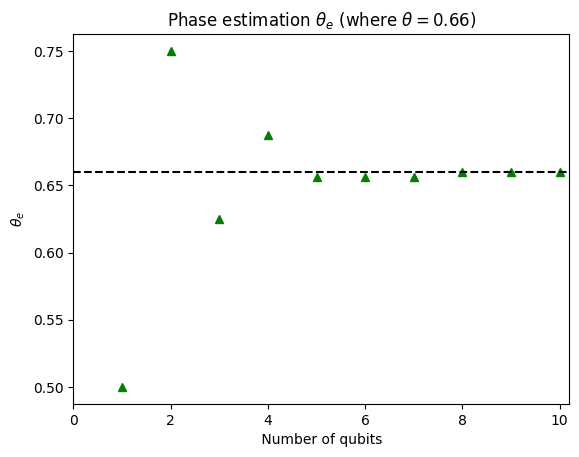

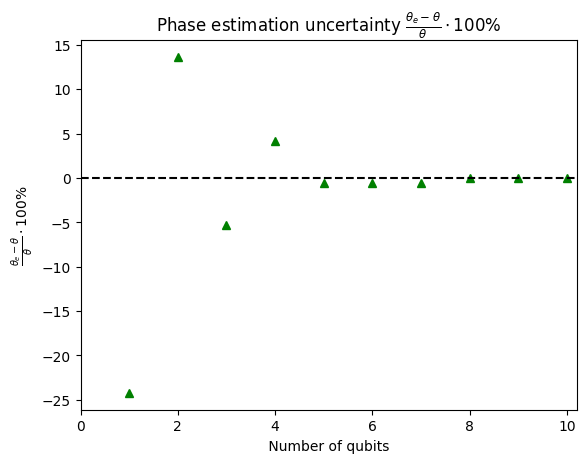

<Figure size 640x480 with 0 Axes>

In [10]:
plot_results(num_qubits, estimated_thetas, qubits_limit, theta_angle)

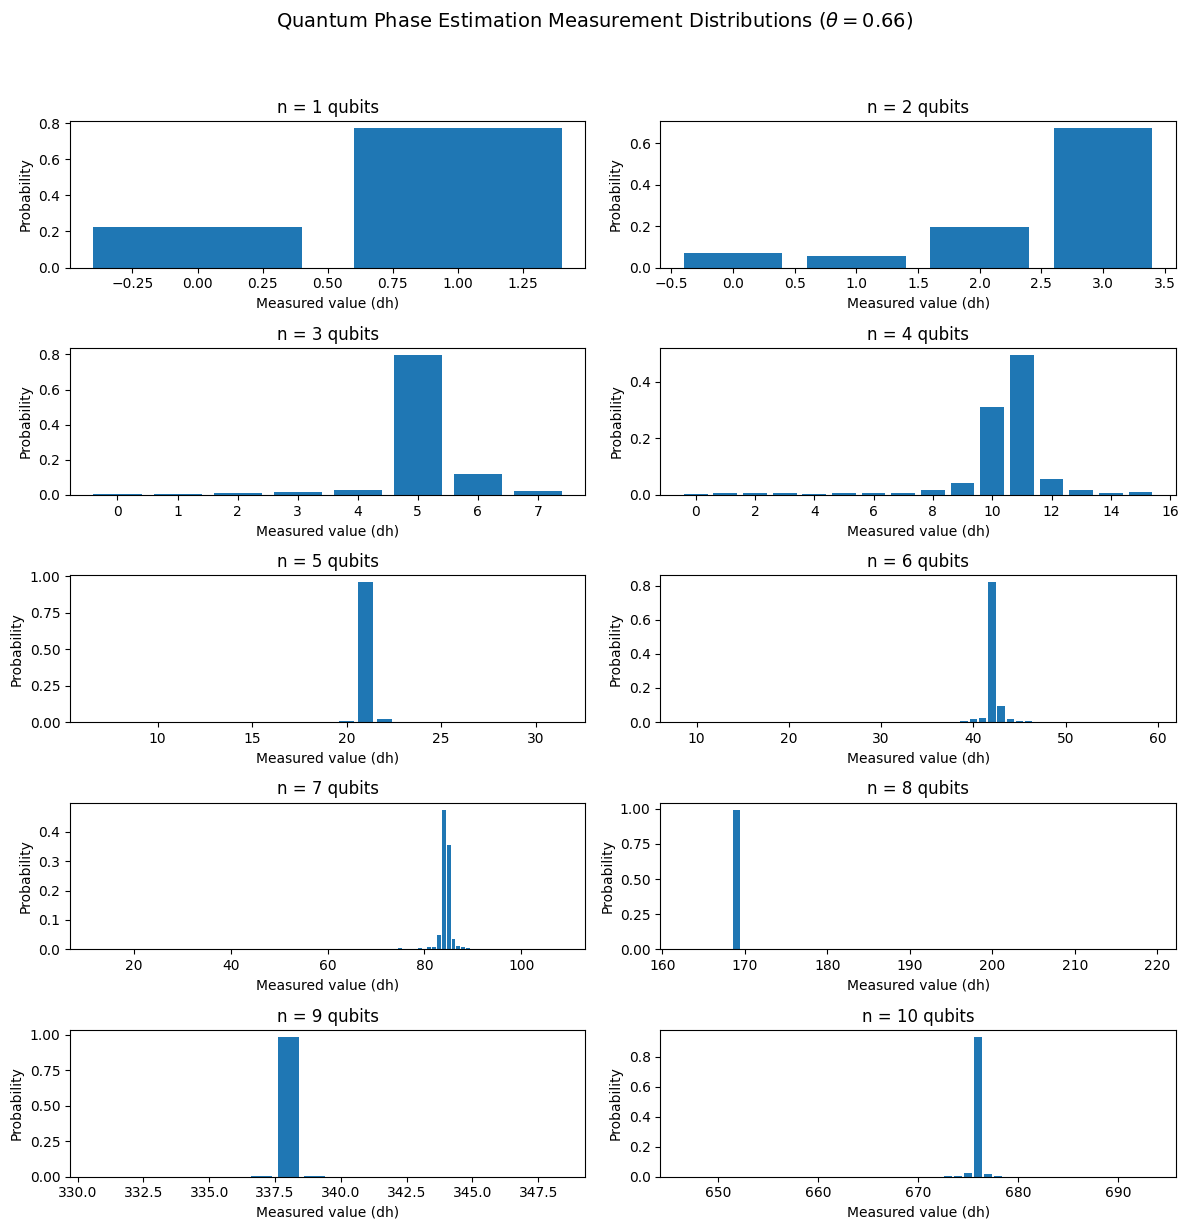

In [11]:
plot_phase_estimation_distributions(results, num_qubits, theta_angle)

## Conclusions

The experimental results demonstrate that the precision of the phase estimation increases with the number of qubits employed in the measuring register. As n increases from 1 to 10, the estimated phase θe​ converges toward the true value θ, resulting in a significant reduction in the percentage of phase estimation uncertainty. While low-qubit systems (such as n=1 or n=2) provide only coarse approximations of the phase, higher-order systems utilize a finer binary decimal representation (ϕ=0.ϕ1​ϕ2​...ϕn​) to capture the value with greater accuracy. Ultimately, the successful implementation in Qiskit confirms that the QPE algorithm effectively translates the phase of a unitary operator into a measurable classical bitstring, provided the register size is sufficient to meet the desired accuracy threshold.